# Regresión lineal simple y múltiple — Fórmula 1
**Aprendizaje Automático · Clase 4 · Aprendizaje Supervisado**

**Alumno:** Tomas Roa

**Objetivo:** aplicar regresión lineal simple y múltiple para predecir una variable continua a partir de otras variables.

## Planteo del problema

**Pregunta:** ¿se puede predecir el **tiempo de la pole position** de un Gran Premio (la vuelta más rápida de la clasificación) a partir de las **características del circuito**?

- **Variable objetivo (continua):** tiempo de la pole, en segundos.
- **Modelo simple:** usa como predictor la **longitud del circuito** (km).
- **Modelo múltiple (4 variables):**
  - **longitud** del circuito (km): cuanto más largo, más tiempo tarda una vuelta;
  - **cantidad de curvas**: en cada curva el auto frena, así que más curvas implican una vuelta más lenta;
  - **zonas de DRS**: tramos donde se abre el alerón trasero para ganar velocidad en recta;
  - **temporada**: los autos evolucionan de un año a otro y suelen ser más rápidos.

Método: 1) Preparación y organización de datos · 2) Exploración de los datos · 3) Creación de modelos de machine learning

## Fuente de los datos

| | |
|---|---|
| **Repositorio** | *Formula 1 Datasets*, de **toUpperCase78** (GitHub) |
| **Enlace** | https://github.com/toUpperCase78/formula1-datasets |
| **Origen de los datos** | Sitio oficial de la Fórmula 1: https://www.formula1.com/ (según indica el autor del repositorio) |
| **Licencia** | GNU General Public License v3.0. El autor pide citar el repositorio original al usar los datos. |
| **Fecha de descarga** | 27/09/2026 |
| **Archivos usados** (carpeta `datos/`) | Calendarios de 2022 a 2025 (`Formula1_2022season_calendar.csv`, etc.), con las características de cada circuito. Resultados de clasificación de 2022 a 2026 (`Formula1_2022season_qualifyingResults.csv`, etc.), con los tiempos de cada piloto en Q1, Q2 y Q3. |

**Nota:** el autor actualiza los archivos de la temporada en curso después de cada Gran Premio. Para reproducir exactamente este análisis hay que usar las copias guardadas en la carpeta `datos/` de este repositorio.

**Cita:** toUpperCase78 (2026). *Formula 1 Datasets* [conjunto de datos]. GitHub. Recuperado el 27/09/2026 de https://github.com/toUpperCase78/formula1-datasets

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # para los gráficos 3D
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import sklearn.metrics as sm

## 1. Preparación y organización de datos
Los datos están repartidos en dos tipos de archivo por temporada:
- **Calendario:** una fila por Gran Premio, con las características del circuito.
- **Clasificación:** una fila por piloto y Gran Premio, con sus tiempos en Q1, Q2 y Q3.

Hay que combinarlos para obtener una tabla con **una fila por Gran Premio**: las características del circuito y el tiempo de la pole.

In [2]:
RUTA = "../datos/"
archivos = {
    2022: ("Formula1_2022season_calendar.csv", "Formula1_2022season_qualifyingResults.csv"),
    2023: ("Formula1_2023season_calendar.csv", "Formula1_2023season_qualifyingResults.csv"),
    2024: ("Formula1_2024season_calendar.csv", "Formula1_2024season_qualifyingResults.csv"),
    2025: ("Formula1_2025Season_Calendar.csv", "Formula1_2025Season_QualifyingResults.csv"),
}

calendario_2025 = pd.read_csv(RUTA + archivos[2025][0])
calendario_2025.head(3)

,Round,Race Date,GP Name,Country,City,Circuit Name,First GP,Number of Laps,Circuit Length(km),Race Distance(km),Lap Record,Record Owner,Record Year,Turns,DRS Zones
0,1,16/03/2025,Louis Vuitton Australian Grand Prix,Australia,Melbourne,Albert Park Circuit,1996,58,5.278,306.124,1:19.813,Charles Leclerc,2024,14,4
1,2,23/03/2025,Heineken Chinese Grand Prix,China,Shanghai,Shanghai International Circuit,2004,56,5.451,305.066,1:32.238,Michael Schumacter,2004,16,2
2,3,06/04/2025,Lenovo Japanese Grand Prix,Japan,Suzuka,Suzuka Circuit,1987,53,5.807,307.471,1:30.965,Kimi Antonelli,2025,18,1


In [3]:
clasificacion_2025 = pd.read_csv(RUTA + archivos[2025][1])
clasificacion_2025.head(3)

,Track,Position,No,Driver,Team,Q1,Q2,Q3,Laps
0,Australia,1,4,Lando Norris,McLaren Mercedes,1:15.912,1:15.415,1:15.096,20
1,Australia,2,81,Oscar Piastri,McLaren Mercedes,1:16.062,1:15.468,1:15.180,18
2,Australia,3,1,Max Verstappen,Red Bull Racing Honda RBPT,1:16.018,1:15.565,1:15.481,17


### Convertir los tiempos a segundos
Los tiempos vienen como texto con formato `minutos:segundos.milésimas` (por ejemplo `1:15.096`). Para usarlos en un modelo hay que pasarlos a números (segundos).

Al revisar los archivos aparecen **errores de tipeo** en algunos tiempos. Por ejemplo:

In [4]:
todos_los_tiempos = pd.concat([pd.read_csv(RUTA + q)[["Q1", "Q2", "Q3"]].stack() for _, q in archivos.values()]).astype(str)
formato_correcto = todos_los_tiempos.str.match(r"^\d:\d\d\.\d{3}$")
print("Tiempos con formato distinto al esperado:")
print(todos_los_tiempos[~formato_correcto].unique())

Tiempos con formato distinto al esperado:
<StringArray>
[        nan, '1:28.6886',       'DNS',  '1:18:580',       'DNF',   '1:29.25',
  '1:14:680',  '1:59:634',  '1:11:785',  '1:11:518', '1:33.0.57',  '1:42:211',
 ':1:42.511',  '1:17:234',  '1:09:656', '1:120.186', '1:120.084']
Length: 17, dtype: str


- `nan` (vacío): los pilotos eliminados en Q1 o Q2 no tienen tiempo en las rondas siguientes.
- `DNF` / `DNS`: el piloto no completó una vuelta o no salió a pista. No hay tiempo.
- `1:28.6886` o `1:29.25`: tienen una cifra de más o de menos, pero se pueden leer igual.
- `1:18:580`: dos puntos en lugar de punto. Se puede corregir a `1:18.580`.
- `:1:42.511`: dos puntos de más al principio. Se corrige a `1:42.511`.
- `1:33.0.57`: un punto de más. Se corrige a `1:33.057`.
- `1:120.186`: no se puede saber cuál era el valor correcto, así que se descarta.

La siguiente función corrige los errores que se pueden reparar y descarta el resto:

In [5]:
def a_segundos(tiempo):
    t = str(tiempo).strip().lstrip(":")                       # ':1:42.511' -> '1:42.511'
    if re.match(r"^\d:\d\d:\d{3}$", t):                     # '1:18:580'  -> '1:18.580'
        t = t[:4] + "." + t[5:]
    if re.match(r"^\d:\d\d\.\d\.\d\d$", t):                # '1:33.0.57' -> '1:33.057'
        t = t[:6] + t[7:]
    if not re.match(r"^\d:\d\d\.\d{2,4}$", t):              # DNF, DNS o error no reparable
        return np.nan
    minutos, segundos = t.split(":")
    return int(minutos) * 60 + float(segundos)

for ejemplo in ["1:15.096", "1:18:580", ":1:42.511", "1:33.0.57", "1:28.6886", "1:120.186", "DNF"]:
    resultado = a_segundos(ejemplo)
    print(f"{ejemplo:>10} -> {round(resultado, 3) if not np.isnan(resultado) else resultado}")

  1:15.096 -> 75.096
  1:18:580 -> 78.58
 :1:42.511 -> 102.511
 1:33.0.57 -> 93.057
 1:28.6886 -> 88.689
 1:120.186 -> nan
       DNF -> nan


### Unir calendario y clasificación
Los Grandes Premios aparecen en el mismo orden en los dos archivos, así que se pueden unir por posición: el primer GP del archivo de clasificación corresponde a la primera fecha del calendario, y así sucesivamente.

Hay una excepción: en **2023** el GP de **Emilia-Romaña (Imola)** figura en el calendario, pero **se canceló por inundaciones** y no tiene clasificación. Hay que sacarlo antes de unir.

El **tiempo de pole** es el mejor tiempo de toda la clasificación de ese GP.

In [6]:
filas = []
for temporada, (arch_cal, arch_clas) in archivos.items():
    cal = pd.read_csv(RUTA + arch_cal)
    clas = pd.read_csv(RUTA + arch_clas)
    if temporada == 2023:
        cal = cal[cal["City"] != "Imola"].reset_index(drop=True)   # GP cancelado

    grandes_premios = list(dict.fromkeys(clas["Track"]))          # en orden de aparición
    assert len(grandes_premios) == len(cal), f"No coinciden los GP en {temporada}"

    for i, gp in enumerate(grandes_premios):
        tiempos = clas.loc[clas["Track"] == gp, ["Q1", "Q2", "Q3"]].stack().map(a_segundos)
        circuito = cal.iloc[i]
        filas.append({
            "temporada": temporada,
            "gran_premio": gp,
            "circuito": circuito["Circuit Name"],
            "longitud_km": circuito["Circuit Length(km)"],
            "curvas": circuito["Turns"],
            "zonas_drs": circuito["DRS Zones"],
            "pole_seg": tiempos.min(),
        })

df = pd.DataFrame(filas)
df.head()

,temporada,gran_premio,circuito,longitud_km,curvas,zonas_drs,pole_seg
0,2022,Bahrain,Bahrain International Circuit,5.412,15,3,90.558
1,2022,Saudi Arabia,Jeddah Corniche Circuit,6.174,27,3,88.200
2,2022,Australia,Albert Park Circuit,5.278,14,2,77.868
3,2022,Emilia Romagna,Autodromo Enzo e Dino Ferrari,4.909,18,1,78.793
4,2022,Miami,Miami International Autodrome,5.412,19,3,88.796


Para comprobar que la unión por orden quedó bien, revisamos que el nombre del GP (del archivo de clasificación) coincida con el circuito (del calendario):

In [7]:
df[["temporada", "gran_premio", "circuito"]].sample(8, random_state=1)

,temporada,gran_premio,circuito
59,2024,Italy,Autodromo Nazionale Monza
73,2025,Miami,Miami International Autodrome
44,2024,Bahrain,Bahrain International Circuit
56,2024,Hungary,Hungaroring
74,2025,Emilia-Romagna,Autodromo Internazionale Enzo e Dino Ferrari
81,2025,Hungary,Hungaroring
84,2025,Azerbaijan,Baku City Circuit
53,2024,Spain,Circuit de Barcelona-Catalunya


Los nombres de los circuitos también tienen inconsistencias: el mismo circuito aparece escrito de distintas formas según la temporada. Los unificamos:

In [8]:
print("Antes:", df["circuito"].nunique(), "nombres distintos")
unificar = {
    "Albert Park Grand Prix Circuit": "Albert Park Circuit",
    "Melbourne Grand Prix Circuit": "Albert Park Circuit",
    "Aurodromo Jose Carlos Pace": "Autodromo José Carlos Pace",
    "Autodromo Jose Carlos Pace": "Autodromo José Carlos Pace",
    "Autodromo Enzo e Dino Ferrari": "Autodromo Internazionale Enzo e Dino Ferrari",
    "Circuit of The Americas": "Circuit of the Americas",
    "Suzuka International Racing Course": "Suzuka Circuit",
}
df["circuito"] = df["circuito"].replace(unificar)
print("Después:", df["circuito"].nunique(), "circuitos")

Antes: 32 nombres distintos
Después: 25 circuitos


In [9]:
print("Filas y columnas:", df.shape)
print("\nValores faltantes por columna:")
print(df.isnull().sum())

Filas y columnas: (92, 7)

Valores faltantes por columna:
temporada      0
gran_premio    0
circuito       0
longitud_km    0
curvas         0
zonas_drs      0
pole_seg       0
dtype: int64


Quedan **92 Grandes Premios** (2022 a 2025) sin valores faltantes. Guardamos la tabla ya preparada en la carpeta `datos/`, así queda disponible sin repetir la limpieza:

In [10]:
df.to_csv(RUTA + "f1_poles_2022_2025.csv", index=False)

## 2. Exploración de los datos (AED)

In [11]:
df.describe().round(2)

,temporada,longitud_km,curvas,zonas_drs,pole_seg
count,92.00,92.00,92.00,92.00,92.00
mean,2023.54,5.18,16.74,2.23,83.33
std,1.12,0.83,3.53,0.79,11.09
min,2022.00,3.34,10.00,1.00,63.97
25%,2023.00,4.36,14.00,2.00,75.04
50%,2024.00,5.28,16.50,2.00,83.00
75%,2025.00,5.81,19.00,3.00,89.74
max,2025.00,7.00,27.00,4.00,113.16


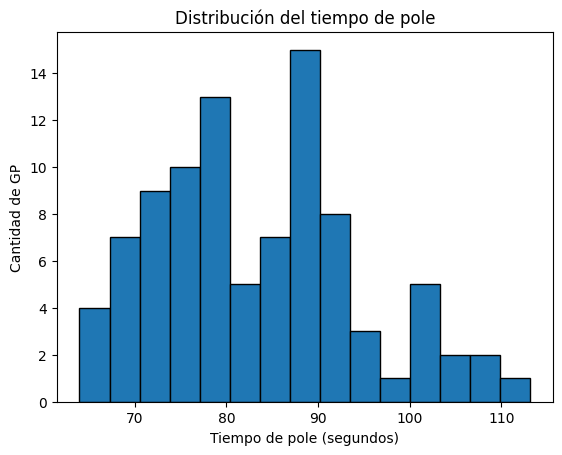

In [12]:
plt.hist(df["pole_seg"], bins=15, edgecolor="black")
plt.title("Distribución del tiempo de pole")
plt.xlabel("Tiempo de pole (segundos)")
plt.ylabel("Cantidad de GP")
plt.show()

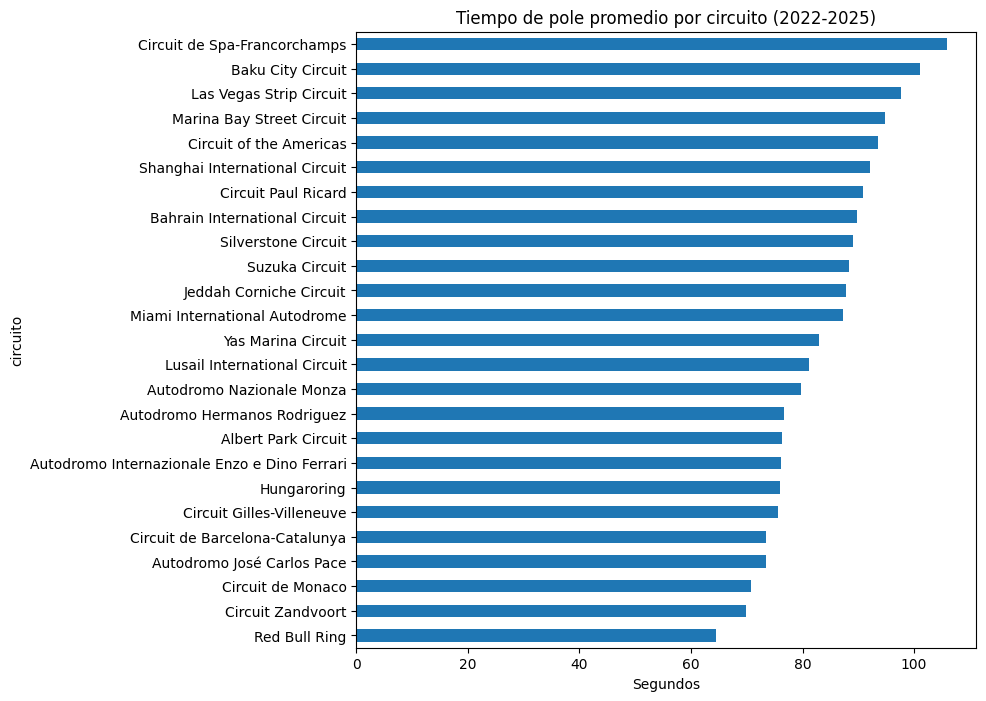

In [13]:
# Tiempo de pole promedio por circuito
df.groupby("circuito")["pole_seg"].mean().sort_values().plot(kind="barh", figsize=(8, 8))
plt.title("Tiempo de pole promedio por circuito (2022-2025)")
plt.xlabel("Segundos")
plt.show()

La vuelta más corta es la del **Red Bull Ring** (Austria), de alrededor de 1 minuto 4 segundos (en promedio), y la más larga la de **Spa-Francorchamps** (Bélgica), de casi 1 minuto 46 segundos (en promedio).

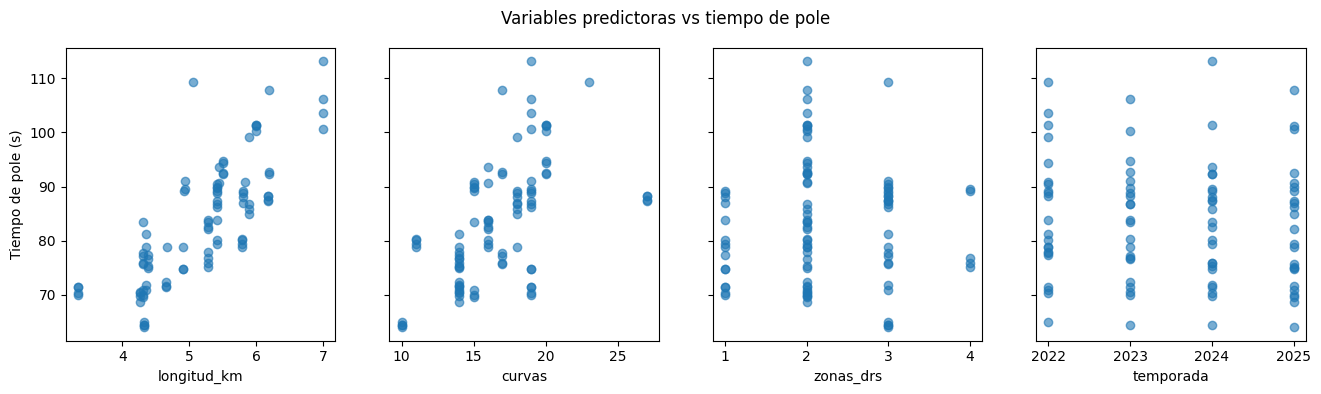

In [14]:
# Relación de cada variable predictora con el tiempo de pole
variables = ["longitud_km", "curvas", "zonas_drs", "temporada"]
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for eje, var in zip(ax, variables):
    eje.scatter(df[var], df["pole_seg"], alpha=0.6)
    eje.set_xlabel(var)
ax[0].set_ylabel("Tiempo de pole (s)")
plt.suptitle("Variables predictoras vs tiempo de pole")
plt.show()

In [15]:
correlaciones = df[variables + ["pole_seg"]].corr()["pole_seg"].drop("pole_seg")
correlaciones.round(2)

longitud_km    0.79
curvas         0.55
zonas_drs      0.01
temporada     -0.08
Name: pole_seg, dtype: float64

In [16]:
# Valores atípicos: circuitos "lentos para su longitud"
df["velocidad_media_kmh"] = df["longitud_km"] / df["pole_seg"] * 3600
df.sort_values("velocidad_media_kmh")[["temporada", "circuito", "longitud_km", "curvas", "pole_seg", "velocidad_media_kmh"]].head(6).round(1)

,temporada,circuito,longitud_km,curvas,pole_seg,velocidad_media_kmh
16,2022,Marina Bay Street Circuit,5.1,23,109.4,166.6
6,2022,Circuit de Monaco,3.3,19,71.4,168.3
27,2023,Circuit de Monaco,3.3,19,71.4,168.3
51,2024,Circuit de Monaco,3.3,19,70.3,171.0
75,2025,Circuit de Monaco,3.3,19,70.0,171.7
64,2024,Autodromo José Carlos Pace,4.3,15,83.4,186.0


**Observaciones:**
- La **longitud** es la variable más relacionada con el tiempo de pole (correlación 0.79): a mayor longitud, más tiempo por vuelta.
- La cantidad de **curvas** también se relaciona (0.55): los circuitos con muchas curvas son más lentos.
- Las **zonas de DRS** y la **temporada** casi no muestran relación a simple vista, pero pueden aportar información cuando se combinan con las otras variables.
- **Monaco** y **Singapur** son valores atípicos: son circuitos callejeros, angostos y con muchas curvas, con velocidades medias mucho más bajas que el resto. En el otro extremo, **Monza** (Italia) es el circuito más rápido.

## 3. Creación de modelos de machine learning

| Modelo | Variables predictoras | Visualización |
|---|---|---|
| **Simple** | longitud | 2D: recta |
| **Múltiple** | longitud, curvas, zonas de DRS, temporada | 2D y 3D: plano |

### 3.1 División en entrenamiento y prueba
- **Entrenamiento (80%)**: los GP con los que el modelo aprende.
- **Prueba (20%)**: GP que el modelo nunca vio, para comprobar si predice bien.

Usamos la misma división para los dos modelos, así la comparación es justa. `random_state=42` hace que la división sea siempre la misma.

In [17]:
X = df[variables]
y = df["pole_seg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("GP de entrenamiento:", len(X_train))
print("GP de prueba:", len(X_test))

GP de entrenamiento: 73
GP de prueba: 19


Definimos funciones que vamos a reutilizar con cada modelo:
- `mostrar_metricas`: calcula las métricas de evaluación vistas en clase.
- `calcular_residuos`: calcula el **residuo** de cada GP, la diferencia entre el valor real y el predicho:

$$\\text{residuo} = y_{real} - y_{predicho}$$

Un residuo positivo significa que la pole real fue **más lenta** de lo que predijo el modelo; uno negativo, que fue **más rápida**.

In [18]:
def mostrar_metricas(y_real, y_pred):
    print("Error absoluto medio (MAE) =", round(sm.mean_absolute_error(y_real, y_pred), 3), "segundos")
    print("Error cuadrático medio (MSE) =", round(sm.mean_squared_error(y_real, y_pred), 3))
    print("Error absoluto mediana =", round(sm.median_absolute_error(y_real, y_pred), 3), "segundos")
    print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_real, y_pred), 3))
    print("Puntuación R2 =", round(sm.r2_score(y_real, y_pred), 3))

def calcular_residuos(y_real, y_pred):
    tabla = df.loc[y_real.index, ["temporada", "circuito"]].copy()
    tabla["real"] = y_real.round(3)
    tabla["predicho"] = np.round(y_pred, 3)
    tabla["residuo"] = (tabla["real"] - tabla["predicho"]).round(3)
    return tabla.sort_values("residuo")

def graficar_residuos(tabla, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(tabla["predicho"], tabla["residuo"])
    ax[0].axhline(0, color="black", linestyle="--")
    ax[0].set_xlabel("Tiempo predicho (s)"); ax[0].set_ylabel("Residuo (s)")
    ax[0].set_title("Residuos vs valores predichos")
    ax[1].hist(tabla["residuo"], bins=8, edgecolor="black")
    ax[1].axvline(0, color="black", linestyle="--")
    ax[1].set_xlabel("Residuo (s)"); ax[1].set_ylabel("Cantidad de GP")
    ax[1].set_title("Distribución de los residuos")
    fig.suptitle(titulo)
    plt.show()

### 3.2 Modelo simple: longitud del circuito → tiempo de pole
#### Entrenamiento

In [19]:
modelo_simple = linear_model.LinearRegression()
modelo_simple.fit(X_train[["longitud_km"]], y_train)
print(f"Ecuación: pole_seg = {modelo_simple.coef_[0]:.3f} * longitud_km + {modelo_simple.intercept_:.3f}")

Ecuación: pole_seg = 10.471 * longitud_km + 29.015


Según el modelo, **cada kilómetro extra de circuito agrega unos 10 segundos** al tiempo de pole. Equivale a recorrer ese kilómetro a unos 350 km/h, algo razonable porque los tramos largos suelen ser rectas.

#### Evaluación

In [20]:
pred_simple = modelo_simple.predict(X_test[["longitud_km"]])
mostrar_metricas(y_test, pred_simple)

Error absoluto medio (MAE) = 5.626 segundos
Error cuadrático medio (MSE) = 43.117
Error absoluto mediana = 4.882 segundos
Puntuación de varianza explicada = 0.492
Puntuación R2 = 0.488


#### Cálculo de residuos

In [21]:
residuos_simple = calcular_residuos(y_test, pred_simple)
residuos_simple

,temporada,circuito,real,predicho,residuo
83,2025,Autodromo Nazionale Monza,78.792,89.674,-10.882
35,2023,Autodromo Nazionale Monza,80.294,89.674,-9.380
10,2022,Red Bull Ring,64.984,74.230,-9.246
72,2025,Jeddah Corniche Circuit,87.294,93.664,-6.370
28,2023,Circuit de Barcelona-Catalunya,72.272,77.779,-5.507
55,2024,Silverstone Circuit,85.819,90.701,-4.882
67,2024,Yas Marina Circuit,82.595,84.313,-1.718
26,2023,Miami International Autodrome,86.814,85.685,1.129
49,2024,Miami International Autodrome,87.241,85.685,1.556
12,2022,Hungaroring,77.377,74.889,2.488


Residuo promedio: 0.575 s


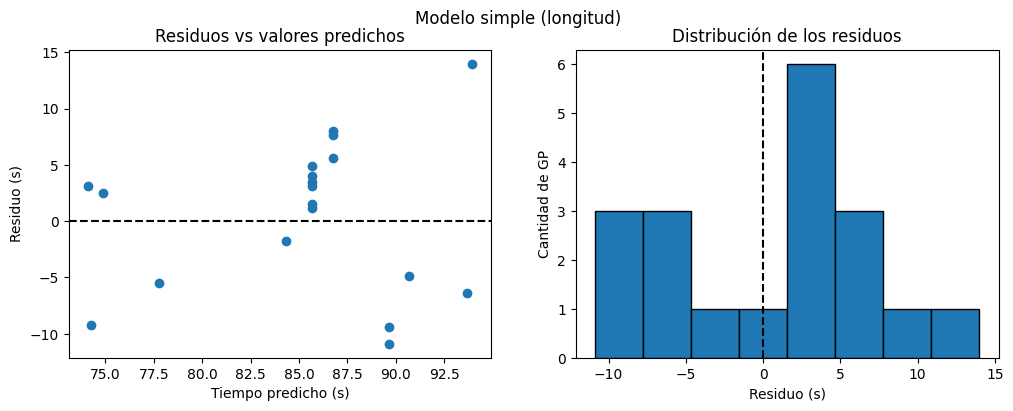

In [22]:
print("Residuo promedio:", round(residuos_simple["residuo"].mean(), 3), "s")
graficar_residuos(residuos_simple, "Modelo simple (longitud)")

Los errores más grandes aparecen en circuitos con características particulares:
- **Residuos negativos** (la pole real fue más rápida que la predicción): **Monza** y el **Red Bull Ring**, circuitos de pocas curvas y rectas largas donde los autos van muy rápido.
- **Residuos positivos** (fue más lenta): el **Circuito de las Américas** y **Bahréin**, con muchas curvas lentas. El caso más extremo es **Las Vegas 2025**, que analizamos más abajo.

La longitud sola no alcanza para capturar el tipo de circuito.

#### Predicciones y visualización 2D

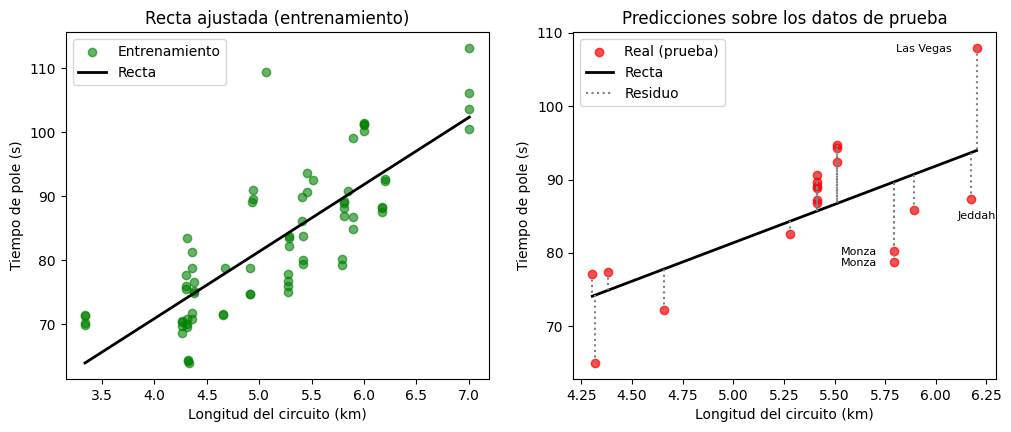

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(X_train["longitud_km"], y_train, color="green", alpha=0.6, label="Entrenamiento")
orden = np.argsort(X_train["longitud_km"].values)
ax[0].plot(X_train["longitud_km"].values[orden], modelo_simple.predict(X_train[["longitud_km"]])[orden], color="black", linewidth=2, label="Recta")
ax[0].set_title("Recta ajustada (entrenamiento)")

ax[1].scatter(X_test["longitud_km"], y_test, color="red", alpha=0.7, label="Real (prueba)")
orden = np.argsort(X_test["longitud_km"].values)
ax[1].plot(X_test["longitud_km"].values[orden], pred_simple[orden], color="black", linewidth=2, label="Recta")
ax[1].vlines(X_test["longitud_km"], y_test, pred_simple, color="gray", linestyle=":", label="Residuo")
for x, yr, circ in zip(X_test["longitud_km"], y_test, df.loc[y_test.index, "circuito"]):
    for clave, nombre, desplazamiento in [("Monza", "Monza", (-38, -3)), ("Vegas", "Las Vegas", (-58, -3)), ("Jeddah", "Jeddah", (-10, -14))]:
        if clave in circ:
            ax[1].annotate(nombre, (x, yr), fontsize=8, xytext=desplazamiento, textcoords="offset points")
ax[1].set_title("Predicciones sobre los datos de prueba")
for eje in ax:
    eje.set_xlabel("Longitud del circuito (km)"); eje.set_ylabel("Tiempo de pole (s)"); eje.legend()
plt.show()

In [24]:
# Predicción de un caso nuevo: un circuito hipotético de 5 km
caso = pd.DataFrame({"longitud_km": [5.0]})
print("Tiempo de pole predicho para un circuito de 5 km:", round(modelo_simple.predict(caso)[0], 2), "segundos")

Tiempo de pole predicho para un circuito de 5 km: 81.37 segundos


### 3.3 Modelo múltiple: longitud, curvas, zonas de DRS y temporada
#### Entrenamiento

In [25]:
modelo_multi = linear_model.LinearRegression()
modelo_multi.fit(X_train, y_train)

coeficientes = pd.Series(modelo_multi.coef_, index=variables).round(3)
print("Ordenada al origen:", round(modelo_multi.intercept_, 2))
coeficientes

Ordenada al origen: 1611.17


longitud_km    8.887
curvas         0.992
zonas_drs      0.329
temporada     -0.786
dtype: float64

**Cómo se leen los coeficientes** (cada uno, manteniendo fijas las demás variables):
- **longitud_km:** cada km extra suma unos 9 segundos a la pole.
- **curvas:** cada curva extra suma alrededor de 1 segundo, porque obliga a frenar y volver a acelerar.
- **zonas_drs:** coeficiente chico. Con las otras variables en cuenta, el DRS casi no cambia el tiempo de pole.
- **temporada:** negativo. Cada año los autos son un poco más rápidos (unas 8 décimas por año), como era esperable por la evolución técnica.

#### Evaluación

In [26]:
pred_multi = modelo_multi.predict(X_test)
mostrar_metricas(y_test, pred_multi)

Error absoluto medio (MAE) = 4.494 segundos
Error cuadrático medio (MSE) = 37.465
Error absoluto mediana = 3.8 segundos
Puntuación de varianza explicada = 0.561
Puntuación R2 = 0.555


#### Cálculo de residuos

In [27]:
residuos_multi = calcular_residuos(y_test, pred_multi)
residuos_multi

,temporada,circuito,real,predicho,residuo
72,2025,Jeddah Corniche Circuit,87.294,101.344,-14.050
10,2022,Red Bull Ring,64.984,70.346,-5.362
55,2024,Silverstone Circuit,85.819,90.358,-4.539
28,2023,Circuit de Barcelona-Catalunya,72.272,76.211,-3.939
35,2023,Autodromo Nazionale Monza,80.294,83.330,-3.036
83,2025,Autodromo Nazionale Monza,78.792,81.757,-2.965
26,2023,Miami International Autodrome,86.814,88.210,-1.396
67,2024,Yas Marina Circuit,82.595,82.954,-0.359
4,2022,Miami International Autodrome,88.796,88.996,-0.200
49,2024,Miami International Autodrome,87.241,87.423,-0.182


Residuo promedio: 0.701 s


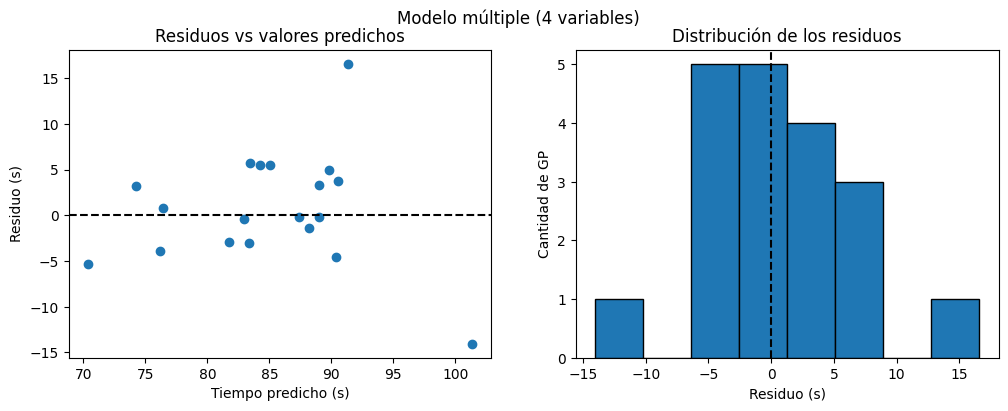

In [28]:
print("Residuo promedio:", round(residuos_multi["residuo"].mean(), 3), "s")
graficar_residuos(residuos_multi, "Modelo múltiple (4 variables)")

Al sumar variables, los residuos se achican en la mayoría de los GP (por ejemplo en Monza, que pasa de −10 a −3 segundos), pero quedan dos casos muy alejados:
- **Jeddah 2025 (residuo ≈ −14 s):** tiene 27 curvas, la mayor cantidad del calendario, y el modelo supone que eso lo hace lento. En realidad casi todas sus curvas son rápidas y se toman a fondo. La variable "curvas" cuenta cuántas hay, pero no cómo son.
- **Las Vegas 2025 (residuo ≈ +17 s):** revisemos sus poles en las tres temporadas:

In [29]:
df[df["circuito"] == "Las Vegas Strip Circuit"][["temporada", "circuito", "pole_seg"]]

,temporada,circuito,pole_seg
42,2023,Las Vegas Strip Circuit,92.726
65,2024,Las Vegas Strip Circuit,92.312
89,2025,Las Vegas Strip Circuit,107.934


En 2023 y 2024 la pole fue de unos 92 segundos, pero en 2025 fue de casi 108: la clasificación de ese año se corrió con **pista mojada**. El modelo no tiene información sobre el clima, así que no puede explicar ese valor. Es un **valor atípico** real, no un error de carga.

#### Predicciones y visualización 2D

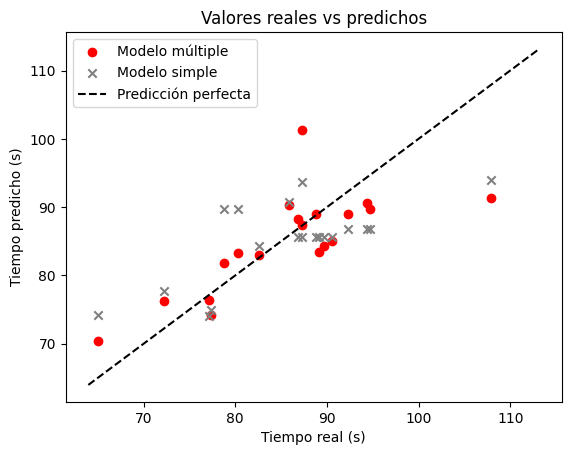

In [30]:
plt.scatter(y_test, pred_multi, color="red", label="Modelo múltiple")
plt.scatter(y_test, pred_simple, color="gray", marker="x", label="Modelo simple")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", label="Predicción perfecta")
plt.xlabel("Tiempo real (s)"); plt.ylabel("Tiempo predicho (s)")
plt.title("Valores reales vs predichos")
plt.legend()
plt.show()

#### Visualización 3D
Con 4 variables el modelo "vive" en 5 dimensiones y no se puede dibujar entero. Lo que sí podemos mostrar es el **plano** que forma con las dos variables más influyentes, **longitud** y **curvas**, dejando las zonas de DRS y la temporada fijas en su valor promedio.

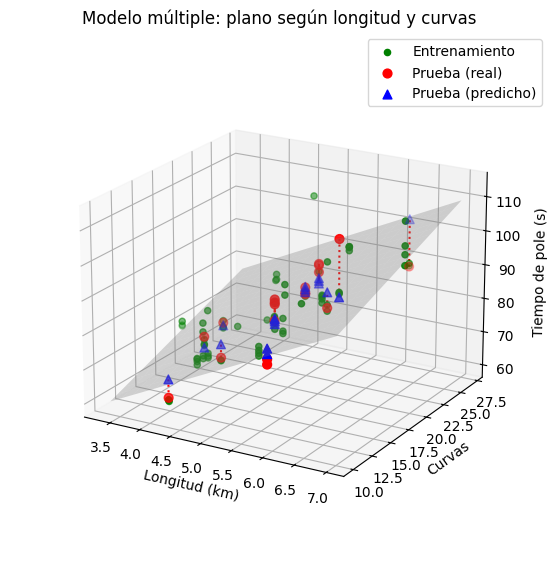

In [31]:
g1 = np.linspace(df["longitud_km"].min(), df["longitud_km"].max(), 20)
g2 = np.linspace(df["curvas"].min(), df["curvas"].max(), 20)
G1, G2 = np.meshgrid(g1, g2)
malla = pd.DataFrame({
    "longitud_km": G1.ravel(),
    "curvas": G2.ravel(),
    "zonas_drs": X_train["zonas_drs"].mean(),
    "temporada": X_train["temporada"].mean(),
})
plano = modelo_multi.predict(malla[variables]).reshape(G1.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(G1, G2, plano, alpha=0.3, color="gray")
ax.scatter(X_train["longitud_km"], X_train["curvas"], y_train, color="green", label="Entrenamiento")
ax.scatter(X_test["longitud_km"], X_test["curvas"], y_test, color="red", s=40, label="Prueba (real)")
ax.scatter(X_test["longitud_km"], X_test["curvas"], pred_multi, color="blue", marker="^", s=40, label="Prueba (predicho)")
for a, b, real, pred in zip(X_test["longitud_km"], X_test["curvas"], y_test, pred_multi):
    ax.plot([a, a], [b, b], [real, pred], color="red", linestyle=":")
ax.set_xlabel("Longitud (km)")
ax.set_ylabel("Curvas")
ax.set_zlabel("Tiempo de pole (s)", labelpad=8)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Modelo múltiple: plano según longitud y curvas")
ax.view_init(elev=20, azim=-60)
ax.legend()
plt.show()

El plano gris muestra cómo cambia el tiempo de pole según la longitud y la cantidad de curvas: sube en las dos direcciones. Los puntos rojos son los tiempos reales de prueba, los triángulos azules lo que predijo el modelo, y las líneas punteadas son los residuos.

> Tip: si en Jupyter escribís `%matplotlib notebook` (o `%matplotlib widget`) al principio de la celda, podés girar el gráfico 3D con el mouse.

In [32]:
# Predicción de un caso nuevo: circuito de 5 km, 16 curvas, 2 zonas de DRS, temporada 2025
caso = pd.DataFrame({"longitud_km": [5.0], "curvas": [16], "zonas_drs": [2], "temporada": [2025]})
print("Tiempo de pole predicho:", round(modelo_multi.predict(caso[variables])[0], 2), "segundos")

Tiempo de pole predicho: 79.67 segundos


### 3.4 Comparación de los modelos

In [33]:
comparacion = pd.DataFrame({
    nombre: {"MAE (s)": sm.mean_absolute_error(y_test, pred),
             "MSE": sm.mean_squared_error(y_test, pred),
             "Varianza explicada": sm.explained_variance_score(y_test, pred),
             "R2": sm.r2_score(y_test, pred)}
    for nombre, pred in [("Simple (longitud)", pred_simple), ("Múltiple (4 variables)", pred_multi)]
}).T.round(3)
comparacion

,MAE (s),MSE,Varianza explicada,R2
Simple (longitud),5.626,43.117,0.492,0.488
Múltiple (4 variables),4.494,37.465,0.561,0.555


### 3.5 Regresión contraída (Ridge)
Aplicamos Ridge al modelo múltiple para ver si la penalización mejora la predicción, por ejemplo reduciendo la influencia de valores atípicos como Monaco o Singapur.

In [34]:
for alpha in [0.1, 1, 10, 100]:
    ridge = linear_model.Ridge(alpha=alpha).fit(X_train, y_train)
    print(f"Ridge alpha={alpha:>5} -> R2 = {sm.r2_score(y_test, ridge.predict(X_test)):.3f}  MAE = {sm.mean_absolute_error(y_test, ridge.predict(X_test)):.2f} s")

Ridge alpha=  0.1 -> R2 = 0.555  MAE = 4.49 s
Ridge alpha=    1 -> R2 = 0.552  MAE = 4.48 s
Ridge alpha=   10 -> R2 = 0.520  MAE = 4.40 s
Ridge alpha=  100 -> R2 = 0.338  MAE = 5.33 s


Ridge da resultados muy parecidos a la regresión lineal común: con alpha chico casi no cambia nada, y con alpha muy grande (100) empeora. Los errores grandes no se deben a coeficientes inestables, sino a casos que estas cuatro variables no pueden describir, como la lluvia en Las Vegas 2025 o las curvas rápidas de Jeddah.

### 3.6 Prueba con datos nuevos: temporada 2026
El modelo se entrenó con 2022-2025. Ahora le pedimos que prediga las poles de **2026**, una temporada que **nunca vio**. Para las características de cada circuito usamos las del calendario 2025.

Dato importante: en 2026 cambió el **reglamento técnico** (autos y motores nuevos). Veamos si el modelo lo "nota".

In [35]:
clas_2026 = pd.read_csv(RUTA + "Formula1_2026Season_QualifyingResults.csv")
print("GP de 2026 disponibles:", list(dict.fromkeys(clas_2026["Track"])))

GP de 2026 disponibles: ['Australia', 'China', 'Japan', 'Miami', 'Canada', 'Monaco', 'Barcelona-Catalunya', 'Austria', 'Asutria', 'Great Britain', 'Belgium', 'Hungary', 'Netherlands', 'Italy', 'Spain']


Otra vez hay que limpiar:
- `Asutria` es un error de tipeo de `Austria`.
- `Barcelona-Catalunya` es el circuito que en 2025 figuraba como `Spain`.
- El último `Spain` de 2026 es el nuevo circuito de **Madrid**. No tenemos sus características en el calendario, así que no se puede predecir y lo dejamos afuera.

In [36]:
clas_2026["Track"] = clas_2026["Track"].replace({"Asutria": "Austria"})
clas_2026 = clas_2026[clas_2026["Track"] != "Spain"]                  # Madrid: circuito nuevo, sin datos
clas_2026["Track"] = clas_2026["Track"].replace({"Barcelona-Catalunya": "Spain"})

pole_2026 = (clas_2026.set_index("Track")[["Q1", "Q2", "Q3"]].stack()
             .map(a_segundos).groupby(level=0).min())

circuitos_2025 = df[df["temporada"] == 2025].set_index("gran_premio")
datos_2026 = circuitos_2025.loc[pole_2026.index, ["circuito", "longitud_km", "curvas", "zonas_drs"]].copy()
datos_2026["temporada"] = 2026
datos_2026["pole_real_2026"] = pole_2026
datos_2026["pole_predicha"] = modelo_multi.predict(datos_2026[variables]).round(3)
datos_2026["pole_2025"] = circuitos_2025.loc[pole_2026.index, "pole_seg"]
datos_2026["residuo"] = (datos_2026["pole_real_2026"] - datos_2026["pole_predicha"]).round(3)
datos_2026[["circuito", "pole_2025", "pole_real_2026", "pole_predicha", "residuo"]]

,circuito,pole_2025,pole_real_2026,pole_predicha,residuo
Track,,,,,
Australia,Albert Park Circuit,75.096,78.518,80.029,-1.511
Austria,Red Bull Ring,63.971,66.113,67.272,-1.159
Belgium,Circuit de Spa-Francorchamps,100.562,104.361,99.668,4.693
Canada,Circuit Gilles-Villeneuve,70.899,72.578,71.551,1.027
China,Shanghai International Circuit,90.641,92.064,82.892,9.172
Great Britain,Silverstone Circuit,84.892,88.111,88.786,-0.675
Hungary,Hungaroring,74.890,77.207,71.399,5.808
Italy,Autodromo Nazionale Monza,78.792,81.786,80.971,0.815
Japan,Suzuka Circuit,86.983,88.778,87.710,1.068


In [37]:
mostrar_metricas(datos_2026["pole_real_2026"], datos_2026["pole_predicha"])
print()
print("Residuo promedio en 2026:", round(datos_2026["residuo"].mean(), 2), "s")
print("Diferencia promedio pole 2026 - pole 2025:", round((datos_2026["pole_real_2026"] - datos_2026["pole_2025"]).mean(), 2), "s")

Error absoluto medio (MAE) = 2.681 segundos
Error cuadrático medio (MSE) = 13.854
Error absoluto mediana = 1.159 segundos
Puntuación de varianza explicada = 0.912
Puntuación R2 = 0.867

Residuo promedio en 2026: 2.17 s
Diferencia promedio pole 2026 - pole 2025: 2.47 s


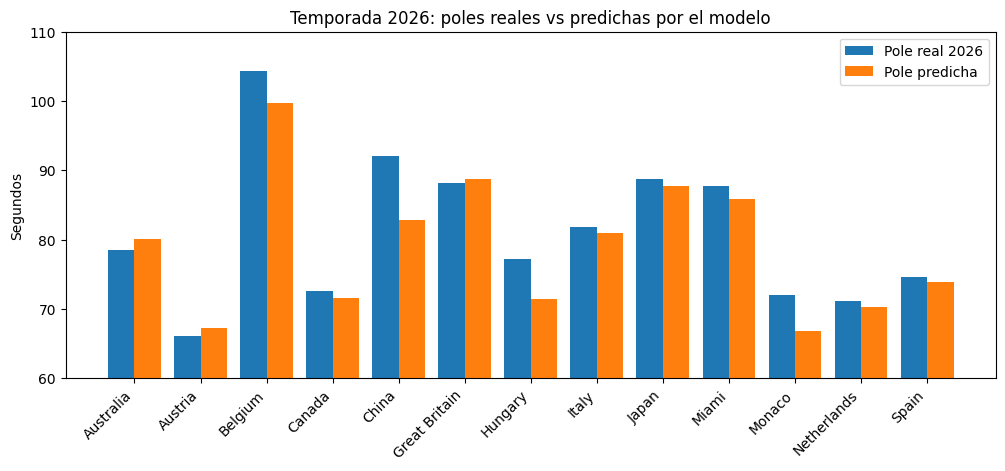

In [38]:
pos = np.arange(len(datos_2026))
plt.figure(figsize=(12, 4.5))
plt.bar(pos - 0.2, datos_2026["pole_real_2026"], width=0.4, label="Pole real 2026")
plt.bar(pos + 0.2, datos_2026["pole_predicha"], width=0.4, label="Pole predicha")
plt.xticks(pos, datos_2026.index, rotation=45, ha="right")
plt.ylim(60, 110)
plt.ylabel("Segundos")
plt.title("Temporada 2026: poles reales vs predichas por el modelo")
plt.legend()
plt.show()

El modelo ordena bien los circuitos: acierta cuáles tienen vueltas largas y cuáles cortas (R2 alto). Pero los residuos son **mayormente positivos**: en promedio, las poles reales de 2026 fueron unos 2 segundos más lentas de lo predicho.

La razón es que el modelo aprendió que "cada año los autos son más rápidos" (coeficiente negativo de la temporada), y en 2026 pasó lo contrario: con el reglamento nuevo, las poles fueron en promedio unos 2,5 segundos **más lentas** que en 2025. Ningún modelo puede anticipar un cambio que no está en los datos con los que aprendió.

El error más grande es **China** (unos 9 s): el modelo predice ese circuito como más rápido de lo que es también en las temporadas anteriores, porque su característica principal, una recta muy larga seguida de curvas muy lentas, no queda reflejada en las variables.

## 4. Conclusiones

| Modelo | MAE (s) | R2 |
|---|---|---|
| Simple (longitud) | 5.63 | 0.49 |
| Múltiple (longitud, curvas, zonas de DRS, temporada) | 4.49 | 0.56 |

- La **longitud del circuito** por sí sola explica casi la mitad de la variación del tiempo de pole: cada kilómetro extra suma unos 10 segundos.
- El **modelo múltiple** mejora la predicción y reduce el error promedio de 5,6 a 4,5 segundos. Los coeficientes tienen sentido: más longitud y más curvas implican una vuelta más lenta, y cada temporada los autos fueron un poco más rápidos. Las zonas de DRS casi no influyen.
- Los **residuos** muestran los límites del modelo: la cantidad de curvas no dice si son rápidas o lentas (Jeddah), y el modelo no sabe nada del clima (Las Vegas 2025, con lluvia).
- **Ridge** no mejora los resultados.
- Con **datos nuevos (2026)** el modelo ordena bien los circuitos, pero se equivoca sistemáticamente porque el cambio de reglamento hizo los autos más lentos, algo imposible de anticipar con datos de 2022-2025.
- **Posibles mejoras:** agregar variables como el tipo de circuito (callejero o permanente), la velocidad en las curvas, las condiciones de pista (seco o mojado) o el reglamento vigente.